In [ ]:
from downloads import *
# from models import *
from modelFuncs import *

In [ ]:
# len embedd, num classes
model = nn.Sequential(
    nn.Linear(400, 1600),
    nn.ReLU(inplace=True),
    nn.Linear(1600, 7), 
    nn.LogSoftmax(dim=1)
    )

best_acc = - np.inf   # init to negative infinity
best_weights = None
train_loss_hist = []
train_acc_hist = []
dev_loss_hist = []
dev_acc_hist = []

def trainingLoop(data, lr, epochs, batchSize, devData):
    batches_per_epoch = len(data)
    # Define the loss
    criterion = nn.NLLLoss()
    # Optimizers require the parameters to optimize and a learning rate
    optimizer = optim.SGD(model.parameters(), lr=lr)
    # creates the devDataLoader
    devLoader = torch.utils.data.DataLoader(featDevData, batch_size=batchSize, shuffle=False)
    # creates the devFeats and devLabels
    devFeats, devLabels = separateData(devData)
    for epoch in range(epochs):
        with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
            bar.set_description(f"Epoch {epoch}")
            epoch_loss = []
            epoch_acc = []
            model.train()
            running_loss = 0
            for i in bar:
                for featureVector, info, gold in data:
                    # need as long to be passed to NILLLoss
                    labels = T.view(gold, len(gold)).type(torch.LongTensor)
                    optimizer.zero_grad() # empty the gradients, otherwise gradients are accumulated.
                    preds = model(featureVector)
                    # print(f'gold: {gold}\noutput: {len(output)}')
                    loss = criterion(preds, labels)
                    loss.backward() # auto-grad 
                    optimizer.step() # update  weights 
                    running_loss += loss.item()
                    # else:
                    # print(f'preds: {preds}\nlabels{labels}')
                    acc = (torch.argmax(preds, 1) == torch.argmax(gold, 1)).float().mean()
                    epoch_loss.append(float(loss))
                    epoch_acc.append(float(acc))
                    # bar.set_postfix(
                    #     loss=float(loss),
                    #     acc=float(acc)
                    # )
            acc = eval(devLoader, model)
            devLabels = T.view(devLabels, len(devLabels)).type(torch.LongTensor)
            # nill = criterion(, devLabels) 
            # nill = float(nill)
            # acc = float(acc)
            train_loss_hist.append(np.mean(epoch_loss))
            train_acc_hist.append(np.mean(epoch_acc))
            # dev_loss_hist.append(nill)
            dev_acc_hist.append(acc)
            print(f"Training epoch {epoch} : loss: {running_loss/len(data)}, dev accuracy: {acc}")

    return train_loss_hist, dev_loss_hist, train_acc_hist, dev_acc_hist, best_weights


In [119]:
batchSize = 64
trainLoader = torch.utils.data.DataLoader(featTrainData, batch_size=batchSize, shuffle=False)
train_loss_hist, dev_loss_hist, train_acc_hist, dev_acc_hist, best_weights = trainingLoop(trainLoader, 0.01, epochs=10, batchSize = batchSize, devData=featDevData)

Epoch 0: 100%|██████████| 169/169 [01:44<00:00,  1.62batch/s]


Training epoch 0 : loss: 61.87957198701843, dev accuracy: 20.453125


Epoch 1: 100%|██████████| 169/169 [01:44<00:00,  1.62batch/s]


Training epoch 1 : loss: 46.51309359124338, dev accuracy: 20.375


Epoch 2: 100%|██████████| 169/169 [01:45<00:00,  1.61batch/s]


...

Training epoch 7 : loss: 4.989373308636755, dev accuracy: 19.859375


Epoch 8: 100%|██████████| 169/169 [01:53<00:00,  1.48batch/s]


Training epoch 8 : loss: 3.8659055560383635, dev accuracy: 19.890625


Epoch 9: 100%|██████████| 169/169 [01:50<00:00,  1.53batch/s]

Training epoch 9 : loss: 3.1227144844156345, dev accuracy: 19.859375


In [125]:
batchSize = 8
devLoader = torch.utils.data.DataLoader(featDevData, batch_size=batchSize, shuffle=False)

In [126]:
eval(devLoader, model)

151.875

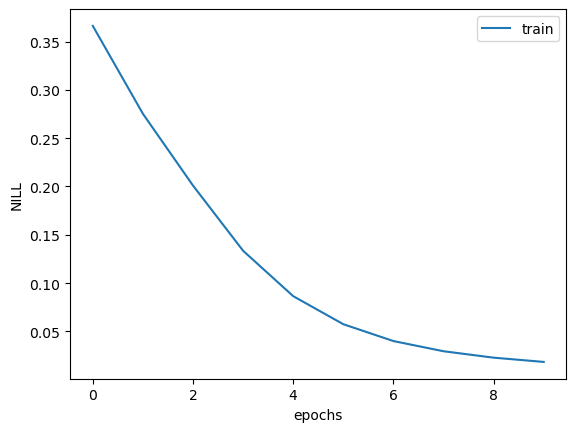

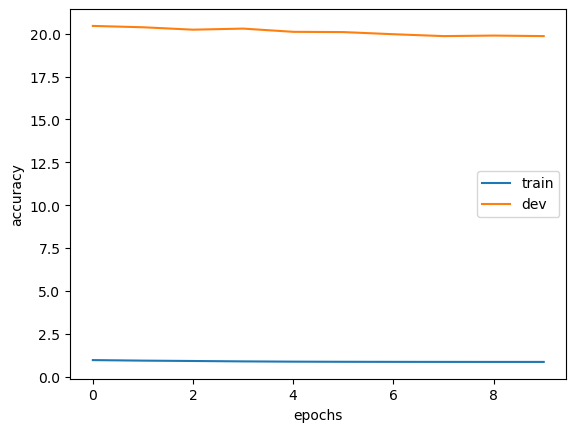

In [122]:
import matplotlib.pyplot as plt
 
plt.plot(train_loss_hist, label="train")
# plt.plot(test_loss_hist, label="dev")
plt.xlabel("epochs")
plt.ylabel("NILL")
plt.legend()
plt.show()
 
plt.plot(train_acc_hist, label="train")
plt.plot(dev_acc_hist, label="dev")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()